<a href="https://colab.research.google.com/github/TEPPN/Animal-Classifier/blob/main/animal_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dittz_12
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:08<00:00, 84.1MB/s]


In [13]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [14]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'wild' 'dog']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
1,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
2,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [15]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=42,
    stratify=data_df['labels']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['labels']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df.shape, val_df.shape, test_df.shape)

(11291, 2) (2419, 2) (2420, 2)


In [16]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [17]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [18]:
train_dataset = CustomImageDataset(dataframe = train_df, transform = transform)
test_dataset = CustomImageDataset(dataframe = test_df, transform = transform)
val_dataset = CustomImageDataset(dataframe = val_df, transform = transform)

In [19]:
print(train_df.iloc[2, 0])

/content/animal-faces/afhq/val/dog/flickr_dog_000245.jpg


In [20]:
train_dataset.__getitem__(2)

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0'),
 tensor(1, device='cuda:0'))

In [21]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

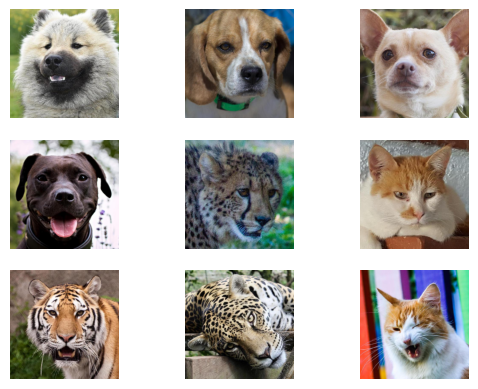

In [22]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [23]:
LR = 1e-4
BATCH_SIZE = 32
EPOCHS = 15

In [24]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [25]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding= 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding= 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding= 1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16), 128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x

In [26]:
model = Net().to(device)

In [27]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [29]:
EPOCHS = 15
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f"""Epoch {epoch +1}/{EPOCHS},
            Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
            Validation Loss {round(total_loss_val/1000, 4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}
        """)

Epoch 1/15,
            Train Loss: 0.2279 Train Accuracy 72.1282
            Validation Loss 0.0267 Validation Accuracy 87.1848
        
Epoch 2/15,
            Train Loss: 0.107 Train Accuracy 88.7787
            Validation Loss 0.0202 Validation Accuracy 90.1199
        
Epoch 3/15,
            Train Loss: 0.0803 Train Accuracy 91.4711
            Validation Loss 0.015 Validation Accuracy 92.6829
        
Epoch 4/15,
            Train Loss: 0.0606 Train Accuracy 93.8624
            Validation Loss 0.013 Validation Accuracy 93.9231
        
Epoch 5/15,
            Train Loss: 0.0527 Train Accuracy 94.7746
            Validation Loss 0.0143 Validation Accuracy 92.7243
        
Epoch 6/15,
            Train Loss: 0.046 Train Accuracy 95.3591
            Validation Loss 0.0108 Validation Accuracy 94.9979
        
Epoch 7/15,
            Train Loss: 0.0391 Train Accuracy 95.8728
            Validation Loss 0.0106 Validation Accuracy 94.9153
        
Epoch 8/15,
            Train Loss: 0.

In [30]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")


Accuracy Score is: 97.562 and Loss is 0.0059


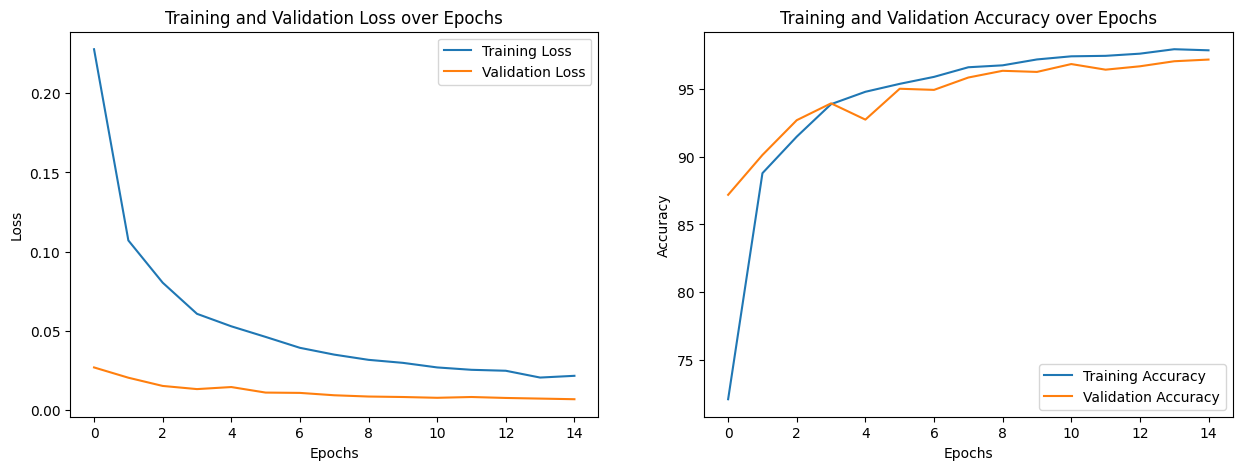

In [31]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [32]:
def predict_image(image_path):
  image = Image.open("/content/cat.jpg").convert('RGB')
  image = transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [34]:
predict_image("/content/cat.jpg")

array(['dog'], dtype=object)